In [16]:
import numpy as np
import matplotlib.pyplot as plt
import collections
import ROOT as root
import awkward as ak
import uproot
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import KernelDensity
from scipy.signal import find_peaks
import sys
import os
import glob

In [11]:
#Focus of this notebook is to take a look at the specific outlier files that were having difficulty getting time segmented. 
#File numbers of interest - 2521, 2506, 2534, 2531
DBSCAN_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/dbscan_clustered/hits_DBSCAN_clustered_epsilon_0.1_2506.npz')
dbscan_hits = DBSCAN_file['first']
occupancy_list = DBSCAN_file['third']

merged_hits_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/multihit/multihit_detector_sim_lossy_2506.npz')
merged_hits_array = merged_hits_file['first']
n_neutrino_events = merged_hits_file['second']
const_hit_array = merged_hits_file['third']

f = root.TFile.Open("/sdf/data/neutrino/summer25/tanaka/nd-production/run-spill-build/MicroProdN4p1_NDComplex_FHC.spill.full/EDEPSIM_SPILLS/0002000/0002500/MicroProdN4p1_NDComplex_FHC.spill.full.0002506.EDEPSIM_SPILLS.root")
edep_events = f.Get("EDepSimEvents")
# Set the branch address.
event = root.TG4Event()
edep_events.SetBranchAddress("Event",root.AddressOf(event))
print("loaded")

loaded


In [12]:
#easiest to just grab our hits and sort by the spill using the DBSCAN hits w/truth spill assigned. 
dbscan_cluster_list = []
spill_level_hits = []
spills_in_file = np.unique(dbscan_hits[:,-4])
for spill_number in spills_in_file:
    spill_level = dbscan_hits[dbscan_hits[:,-4] == spill_number]
    spill_hits_filtered = spill_level
    selected_info = spill_level[:,0:10]
    hit_time_range = max(selected_info[:,5]) - min(selected_info[:,5])
    #now that we are aware of the problem, lets just delete these hits from our array. 
    if hit_time_range > 1000000000:
        rel_time = min(selected_info[:,5])
        ceiling_time = rel_time + 1000000000
        indices = np.where([selected_info[:,5] > ceiling_time])[1][0] #grab index of hits greater than ceiling time.
        selected_info = np.delete(selected_info, indices, axis = 0)
        print(f'deleted index {indices} from spill {spill_number}')
        

    spill_level_hits.append(selected_info)
        
    #spill_level_hits.append(spill_level[:,0:10])

    
#print(spill_level_hits[0])

deleted index 8597 from spill 8.0


In [13]:
#our current KDE logic. 
def MakeKDSegments(hits, bandwidth = 15, mesh_points = 1000, plot = False):
    
    hit_ts = hits[:,5] #extract just the time series data. 
    
    hit_ts_reshaped = hit_ts.reshape(-1, 1)

    # KDE fitting using a gaussian kernel. 
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(hit_ts_reshaped)

    # Evaluate KDE on a fine grid - project our function onto a fine grid to look for local minima
    #This is a necessary step to be able to find our local minima numerically. Basically the kde gives us our functional form, we need to plot it on points to get out the pdf. 
    #The plotting with the points is accomplished by pulling the score_samples method, which returns log likelihoods. We then convert these into actually probabilitiy densities. 
    t_plot = np.linspace(hit_ts.min() - 2, hit_ts.max() + 2, mesh_points).reshape(-1, 1) 
    log_dens = kde.score_samples(t_plot)
    dens = np.exp(log_dens)

    # Find valleys in KDE curve (ie, local minima)
    #Can use scipy peak finding, but invert data so we are really finding the local minima! Returns indices
    inverted = -dens
    valleys, _ = find_peaks(inverted)
    valley_positions = t_plot[valleys].flatten() #this step maps our indices onto actual times. 

    # Assign cluster index based on which region the point falls into
    def assign_cluster(t, boundaries):
        for i, b in enumerate(boundaries): #will loop through boundaries and the last one assigned will be the one it fits into.
            if t < b:
                return(i)
        return(len(boundaries))

    labels = np.array([assign_cluster(t, valley_positions) for t in hit_ts]) #assign labels to our hits. 

    
    if (plot == True): #output a KDE plot
        plt.plot(t_plot[:, 0], dens, label="KDE")
        plt.scatter(hit_ts, np.zeros_like(hit_ts), c=labels, cmap='tab20', s=50, label="Time Segments")
        for v in valley_positions:
            plt.axvline(v, color='gray', linestyle='--', linewidth=1)
        plt.title("KDE-based hit Clustering")
        plt.xlabel("Hit Time")
        plt.yticks([])
        plt.legend()
        plt.show()

    print(f"We found {len(np.unique(labels))} clusters")
    clusters_added = np.column_stack((hits, labels)) #save our data with cluster labels added to the end of each hit row. 
    
    return(clusters_added)

In [14]:
spills_segmented = []
for i, spill_hits in enumerate(spill_level_hits):
    spills_segmented.append(MakeKDSegments(spill_hits, 20, 10000, False))
    #print(f'finished KDE {i}')

We found 108 clusters
We found 114 clusters
We found 112 clusters
We found 110 clusters
We found 118 clusters
We found 113 clusters
We found 118 clusters
We found 102 clusters
We found 110 clusters
We found 101 clusters
We found 107 clusters
We found 103 clusters
We found 116 clusters


In [266]:
spill_number_high = 1

21362.178518533707


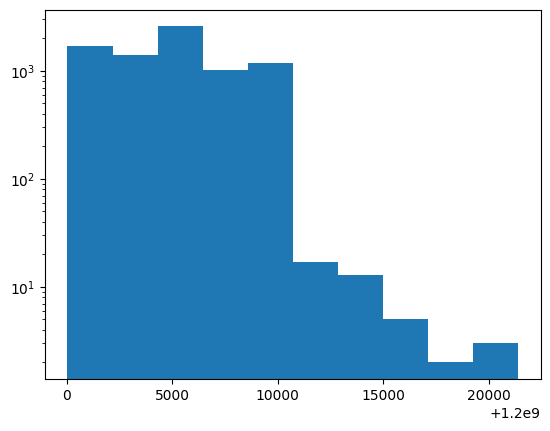

In [267]:
plt.hist(spills_segmented[spill_number_high][:,5])
plt.yscale('log')
print(max(spills_segmented[spill_number_high][:,5]) - min(spills_segmented[spill_number_high][:,5]))

In [258]:
index = np.argmax(spills_segmented[spill_number_high][:,5])
print(index)

8853


In [259]:
weird_event = spills_segmented[spill_number_high][index]
weird_nn = weird_event[0]
weird_hn = weird_event[1]

In [260]:
class TMS_hit_simple:
    def __init__(self, tms_hit_seg, neutrino_number, hit_number):
        self.tms_hit_seg = tms_hit_seg
        self.neutrino_number = neutrino_number #associated with what neutrino vertex
        self.hit_number = hit_number #which TMS hit in the event
        self.x_diff = 0.
        self.y_diff = 0.
        self.z_diff = 0.
        self.Dx = 0.
        
    #Defining attributes based on the tms_hit_seg, avg position in each dimension plus time and energy deposition
    def GetNeutrinoNumber(self):
        return(self.neutrino_number)
        
    def GetHitNumber(self):
        return(self.hit_number)
        
    def GetHitX(self):
        x_pos = (self.tms_hit_seg.GetStart()[0] + self.tms_hit_seg.GetStop()[0]) / 2 
        return(x_pos)
        
    def GetHitY(self):
        y_pos = (self.tms_hit_seg.GetStart()[1] + self.tms_hit_seg.GetStop()[1]) / 2
        return(y_pos)
        
    def GetHitZ(self):
        z_pos = (self.tms_hit_seg.GetStart()[2] + self.tms_hit_seg.GetStop()[2]) / 2
        return(z_pos)
        
    def GetHitT(self):
        time = (self.tms_hit_seg.GetStart()[3] + self.tms_hit_seg.GetStop()[3]) / 2
        return(time)
        
    def GetDx(self):
        self.x_diff = (self.tms_hit_seg.GetStart()[0] - self.tms_hit_seg.GetStop()[0])
        self.y_diff = (self.tms_hit_seg.GetStart()[1] - self.tms_hit_seg.GetStop()[1])
        self.z_diff = (self.tms_hit_seg.GetStart()[2] - self.tms_hit_seg.GetStop()[2])
        self.Dx = ((self.x_diff)**2 + (self.y_diff)**2 + (self.z_diff)**2)**(1/2)
        return(self.Dx)
        
    def GetPrimaryDeposit(self):
        PrimaryDeposit = self.tms_hit_seg.GetEnergyDeposit()
        return(PrimaryDeposit)

In [261]:
edep_events.GetEntry(int(weird_nn))
hit_segments = event.SegmentDetectors['volTMS']
true_hits = []
for i in range(hit_segments.size()):
    hit_true = TMS_hit_simple(hit_segments[i], weird_nn, i)
    hit_truth_data = np.array(( hit_true.GetNeutrinoNumber(),  hit_true.GetHitNumber(), hit_true.GetHitT() ))    
    true_hits.append(hit_truth_data)

In [262]:
trackid = (event.SegmentDetectors['volTMS'])[int(weird_hn)].Contrib[0]
print(trackid)

138


In [263]:
pdgid = (event.Trajectories)[trackid].GetPDGCode()
print(pdgid)
parent_id = (event.Trajectories)[trackid].GetParentId()
parent_pdgid = (event.Trajectories)[parent_id].GetPDGCode()
print(parent_pdgid)

2212
2112


In [264]:
hit_array = np.vstack(true_hits)

In [265]:
hit_array[hit_array[:,1] == weird_hn]

array([[5.03100000e+03, 3.92000000e+02, 3.66246984e+12]])

In [17]:
#We did a run on a larger chunk of files lets see how it went. 
dbscan_clustered_directory = '/sdf/data/neutrino/summer25/ktwall/tms_timing/dbscan_clustered' 
dbscan_clustered_paths = glob.glob(os.path.join(dbscan_clustered_directory, "*.npz")) 
print(dbscan_clustered_paths)

['/sdf/data/neutrino/summer25/ktwall/tms_timing/dbscan_clustered/hits_DBSCAN_clustered_epsilon_0.1_2530.npz', '/sdf/data/neutrino/summer25/ktwall/tms_timing/dbscan_clustered/hits_DBSCAN_clustered_epsilon_0.1_2465.npz', '/sdf/data/neutrino/summer25/ktwall/tms_timing/dbscan_clustered/hits_DBSCAN_clustered_epsilon_0.1_2520.npz', '/sdf/data/neutrino/summer25/ktwall/tms_timing/dbscan_clustered/hits_DBSCAN_clustered_epsilon_0.1_2547.npz', '/sdf/data/neutrino/summer25/ktwall/tms_timing/dbscan_clustered/hits_DBSCAN_clustered_epsilon_0.1_2508.npz', '/sdf/data/neutrino/summer25/ktwall/tms_timing/dbscan_clustered/hits_DBSCAN_clustered_epsilon_0.1_2515.npz', '/sdf/data/neutrino/summer25/ktwall/tms_timing/dbscan_clustered/hits_DBSCAN_clustered_epsilon_0.1_2461.npz', '/sdf/data/neutrino/summer25/ktwall/tms_timing/dbscan_clustered/hits_DBSCAN_clustered_epsilon_0.1_2480.npz', '/sdf/data/neutrino/summer25/ktwall/tms_timing/dbscan_clustered/hits_DBSCAN_clustered_epsilon_0.1_2468.npz', '/sdf/data/neutrin

In [31]:
big_pe_eff = []
big_hit_eff = []
big_occupancy = [] 
spill_accuracy = []
index = 0
spill_number = []
for file_path in dbscan_clustered_paths:
    with np.load(file_path) as file:
        #quickly check the spill stuff
        if 1 == 1:
            #print(file_path)
            #print(max(file['third']))
            n_spills = len(np.unique(file['first'][:,-4]))
            spill_number.append(n_spills)
            big_pe_eff.append(file['second'][:,2])
            big_hit_eff.append(file['second'][:,1])
            big_occupancy.append(file['third'])
        
big_pe_array = np.hstack(big_pe_eff)
big_hit_array = np.hstack(big_hit_eff)
big_occupancy_array = np.hstack(big_occupancy)

Text(0.5, 0, 'Cluster Occupancy')

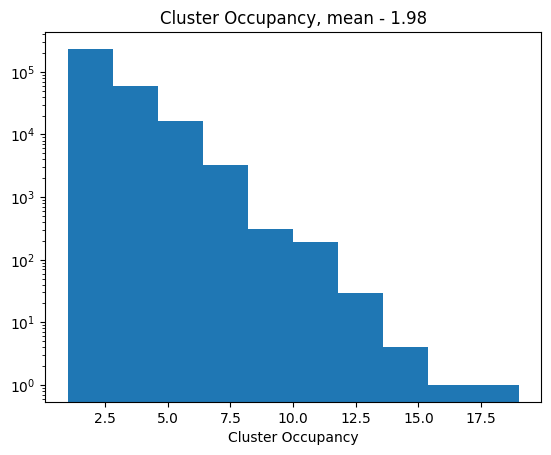

In [35]:
#will have to make these plots look very pretty!

plt.hist(big_occupancy_array)
plt.yscale('log')
plt.title(f'Cluster Occupancy, mean - {np.mean(big_occupancy_array):.2f}')
plt.xlabel('Cluster Occupancy')

Text(0.5, 1.0, 'Cluster PE Efficiency, mean - 0.93')

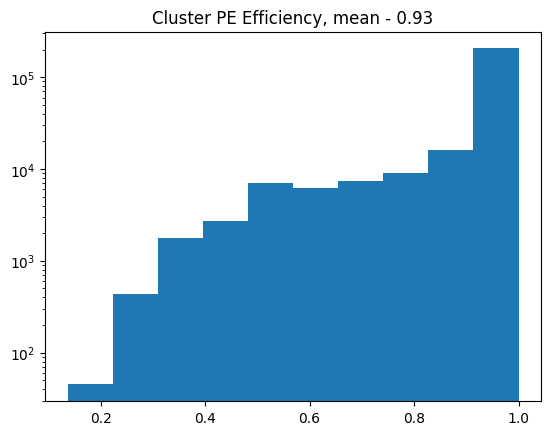

In [33]:
plt.hist(big_pe_array)
plt.yscale('log')
plt.title(f'Cluster PE Efficiency, mean - {np.mean(big_pe_array):.2f}')

Text(0.5, 1.0, 'Cluster Hit Efficiency, mean - 0.89')

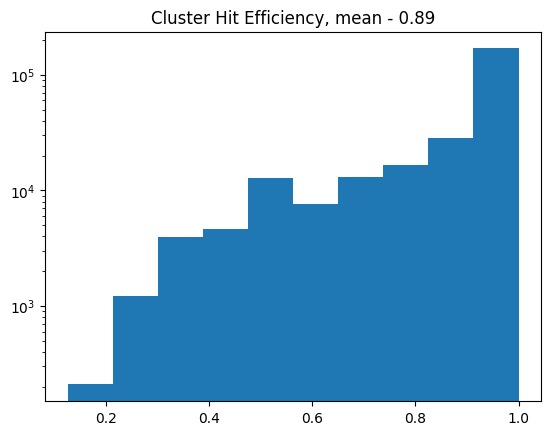

In [34]:
plt.hist(big_hit_array)
plt.yscale('log')
plt.title(f'Cluster Hit Efficiency, mean - {np.mean(big_hit_array):.2f}')